# Patent Citation Network

U.S. patent dataset is maintained by the [National Bureau of Economic Research](http://www.nber.org/). The data set spans 37 years (January 1, 1963 to December 30, 1999), and includes all the utility patents granted during that period, totaling 3,923,922 patents. The citation graph includes all citations made by patents granted between 1975 and 1999, totaling 16,522,438 citations. For the patents dataset there are 1,803,511 nodes for which we have no information about their citations (we only have the in-links).

The data was originally released by [NBER](http://www.nber.org/patents/). The dataset can be found at this link: [Stanford Patent Citation Network](https://snap.stanford.edu/data/cit-Patents.html)

## Import Packages

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

## Import data

In [2]:
patent = pd.read_csv(
    "http://snap.stanford.edu/data/cit-Patents.txt.gz",
    compression="gzip",
    sep="\t",
    names=["start_node", "end_node"],
    skiprows=5
)

In [3]:
patent.head()

,start_node,end_node
0,3858241,1324234
1,3858241,3398406
2,3858241,3557384
3,3858241,3634889
4,3858242,1515701


In [4]:
patent.shape

(16518947, 2)

## Build Recommendation System

build a recommendation system based on Node2Vec with the patent information, remember to do a descriptive analysis and apply visualizations.

Also, remember that when making a recommendation about which patent should be associated with another, make a visualization of the recommendation.

IMPORTAR LIBRERIAS

In [5]:
#!pip install numpy==3.2.5
#!pip install numpy==3.0.0
#!pip install -q node2vec

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==3.0.0 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.19.1, 1.19.2, 1.19.3, 1.19.4, 1.19.5, 1.20.0, 1.20.1, 1.20.2, 1.20.3, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.22.2, 1.22.3, 1.22.4, 1.23.0, 1.23.1, 1.23.2, 1.23.3, 1.23.

##Análisis Descriptivo y Visualización del Grafo

Descargar y cargar los datos

In [6]:
url = "http://snap.stanford.edu/data/cit-Patents.txt.gz"
df = pd.read_csv(url, compression='gzip', sep='\t', skiprows=4, header=None, names=['cited', 'citing'])

Creación del grafo dirigido

In [7]:
G = nx.from_pandas_edgelist(df, source='cited', target='citing', create_using=nx.DiGraph())

Análisis Descriptivo Inicial

In [15]:
print(f"Número de nodos (patentes): {G.number_of_nodes()}")
print(f"Número de aristas (citas): {G.number_of_edges()}")
print(f"Densidad del grafo: {nx.density(G):.6f}")
print(f"Grado promedio: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

Número de nodos (patentes): 3774768
Número de aristas (citas): 16518948
Densidad del grafo: 0.000001
Grado promedio: 8.75


El grafo en cuestión representa una red de patentes en la que cada nodo corresponde a una patente individual, con un total de 3,774,768 nodos. Esto indica que el conjunto de datos abarca un volumen muy grande de patentes, probablemente correspondiente a una base de datos nacional o internacional de propiedad intelectual. El gran número de nodos sugiere una vasta cantidad de información técnica y científica relacionada entre sí a través de citas.

En cuanto a las conexiones entre estas patentes, el grafo contiene 16,518,948 aristas, que representan las citas de una patente a otra. Como estas relaciones son direccionales (una patente cita a otra específica), se trata de un grafo dirigido. Este tipo de estructura es común en redes de conocimiento, donde la dirección de la relación tiene un significado importante, en este caso, el flujo de influencia o dependencia tecnológica.

La densidad del grafo es extremadamente baja, con un valor de 0.000001. Esta cifra refleja el hecho de que, aunque hay millones de conexiones, estas representan una fracción diminuta del total de conexiones posibles entre todas las patentes. En otras palabras, la mayoría de las patentes no están conectadas entre sí directamente, lo que es característico de las redes de citas: cada documento solo hace referencia a una pequeña porción del universo total disponible.

Por último, el grado promedio del grafo es de 8.75. Esto significa que, en promedio, cada patente cita o es citada por unas nueve otras patentes. Aunque este número pueda parecer bajo, es coherente con la estructura de una red de citas, donde las relaciones son selectivas y dirigidas. En conjunto, estos datos describen una red amplia, compleja y dispersa, típica de los sistemas de innovación tecnológica.






Distribución de grados de entrada, salida y estadísticas iniciales

In [16]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
print("\nEstadísticas de grado de entrada:")
print(pd.Series(in_degrees).describe())
print("\nEstadísticas de grado de salida:")
print(pd.Series(out_degrees).describe())


Estadísticas de grado de entrada:
count    3.774768e+06
mean     4.376149e+00
std      6.654673e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      5.000000e+00
max      7.790000e+02
dtype: float64

Estadísticas de grado de salida:
count    3.774768e+06
mean     4.376149e+00
std      7.781205e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      7.700000e+02
dtype: float64


Este conjunto de estadísticas describe el grado de entrada y el grado de salida de un grafo dirigido en el que los nodos representan patentes y las aristas, las citas entre ellas. El grado de entrada indica cuántas veces una patente ha sido citada por otras, mientras que el grado de salida representa cuántas otras patentes ha citado una patente en particular.

Para el grado de entrada, se observa que hay 3,774,768 nodos (patentes), lo cual concuerda con el tamaño total del grafo. El grado de entrada promedio es de aproximadamente 4.38, lo que significa que, en promedio, cada patente ha sido citada por unas cuatro otras patentes. La desviación estándar es de aproximadamente 6.65, lo que indica una dispersión moderada: aunque muchas patentes reciben pocas citas, hay algunas que reciben muchas más. El valor mínimo es 0, lo que implica que existen patentes que no han sido citadas nunca, y el máximo es 779, lo que señala la existencia de patentes muy influyentes, que han sido citadas cientos de veces. Los percentiles refuerzan esta asimetría: el 25% de las patentes ha sido citado solo una vez o menos, el 50% ha sido citado dos veces o menos, y el 75% cinco veces o menos.

En cuanto al grado de salida, el promedio también es de 4.38, lo cual sugiere una simetría general entre las citas hechas y recibidas, como se esperaría en una red de citas cerrada donde cada cita tiene un origen y un destino. Sin embargo, la distribución del grado de salida tiene una desviación estándar un poco mayor (7.78), indicando una variabilidad ligeramente más amplia en cuántas citas hace cada patente. También aquí el mínimo es 0, lo que indica que hay patentes que no citan a ninguna otra, y el máximo es 770. Notablemente, el 25% de las patentes no cita a ninguna otra (grado de salida igual a 0), lo cual puede deberse a que muchas patentes son de naturaleza original o fundacional, o simplemente más recientes. La mediana es de 2 citas salientes y el 75% de las patentes cita hasta 6 otras.


Visualización de distribuciones de grado

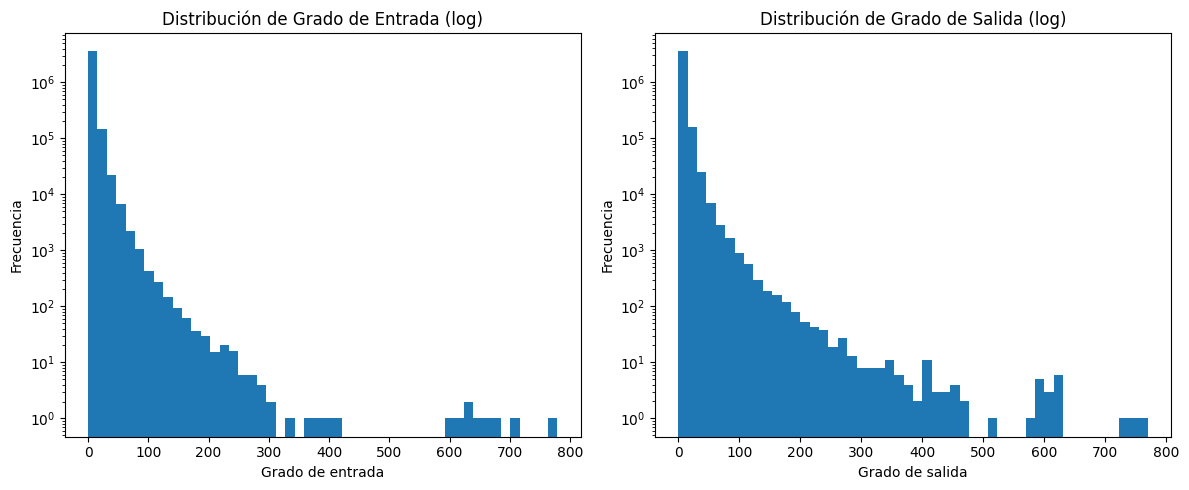

In [17]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(list(in_degrees.values()), bins=50, log=True)
plt.title('Distribución de Grado de Entrada (log)')
plt.xlabel('Grado de entrada')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(list(out_degrees.values()), bins=50, log=True)
plt.title('Distribución de Grado de Salida (log)')
plt.xlabel('Grado de salida')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

La imagen muestra dos histogramas logarítmicos que representan la distribución del grado de entrada y salida en un grafo dirigido. En el gráfico de la izquierda se observa la distribución del grado de entrada, es decir, cuántas conexiones recibe cada nodo. Se evidencia que la mayoría de los nodos tienen un grado de entrada bajo, lo cual es común en muchas redes reales. Sin embargo, también hay una pequeña cantidad de nodos con un grado de entrada muy alto, lo que indica la presencia de “hubs” o nodos altamente conectados.

De manera similar, el gráfico de la derecha representa la distribución del grado de salida, es decir, cuántas conexiones salen de cada nodo. La forma de la distribución es parecida a la del grado de entrada: muchos nodos con pocos enlaces salientes y unos pocos con un número muy alto de conexiones. Esta simetría en ambas distribuciones sugiere que, aunque el grafo es dirigido, la estructura general tiende a un equilibrio en términos de dispersión de enlaces.

Ambas distribuciones siguen una tendencia típica de redes de tipo “scale-free” (libre de escala), donde la frecuencia de nodos disminuye a medida que el grado aumenta, siguiendo posiblemente una ley de potencias. Este tipo de redes es común en fenómenos del mundo real como las redes sociales, los enlaces web o las redes de citación académica. La escala logarítmica de los ejes verticales permite visualizar mejor estas diferencias extremas entre nodos muy conectados y nodos con pocas conexiones.

La existencia de hubs tiene implicaciones importantes: hace que la red sea robusta frente a fallos aleatorios (ya que la mayoría de los nodos son poco relevantes), pero también la vuelve vulnerable a ataques dirigidos a los nodos centrales. Además, esta estructura favorece la rápida propagación de información o influencia, ya que los nodos con mayor grado actúan como superdifusores. Esto sugiere que métricas adicionales como el PageRank, la centralidad de intermediación o el coeficiente de clustering podrían aportar más información sobre el rol de los nodos dentro de la red.

Top de patentes más citadas (grado de entrada)

In [18]:
top_cited = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 patentes más citadas:")
for patent, count in top_cited:
    print(f"Patente {patent}: {count} citas")


Top 10 patentes más citadas:
Patente 4723129: 779 citas
Patente 4463359: 716 citas
Patente 4740796: 678 citas
Patente 4345262: 658 citas
Patente 4558333: 654 citas
Patente 4313124: 633 citas
Patente 4683195: 630 citas
Patente 4459600: 613 citas
Patente 4683202: 605 citas
Patente 3953566: 411 citas


Top patentes que más citan (grado de salida)

In [19]:
top_citing = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 patentes que más citan:")
for patent, count in top_citing:
    print(f"Patente {patent}: {count} citas a otras")


Top 10 patentes que más citan:
Patente 5795784: 770 citas a otras
Patente 5887243: 745 citas a otras
Patente 5856194: 737 citas a otras
Patente 5855655: 626 citas a otras
Patente 5891229: 626 citas a otras
Patente 5908495: 624 citas a otras
Patente 5858586: 623 citas a otras
Patente 6008268: 623 citas a otras
Patente 5885337: 621 citas a otras
Patente 5837429: 612 citas a otras


In [20]:
# Medidas de Centralidad
print("\nCalculando medidas de centralidad (puede tomar tiempo para grafos grandes)...")

num_weakly_connected_components = nx.number_weakly_connected_components(G)
print(f"\nNúmero de componentes débilmente conectados: {num_weakly_connected_components}")

if num_weakly_connected_components > 1:
    # Si hay más de un componente, podemos analizar el tamaño del componente más grande
    weakly_connected_components = list(nx.weakly_connected_components(G))
    largest_wcc = max(weakly_connected_components, key=len)
    print(f"Tamaño del componente débilmente conectado más grande: {len(largest_wcc)}")
    print(f"Proporción del componente más grande respecto al total de nodos: {len(largest_wcc) / G.number_of_nodes():.4f}")

# Para un análisis más detallado, podríamos mirar la distribución del tamaño de los componentes

# Estadísticas sobre los valores de grado de entrada y salida
print("\nEstadísticas detalladas del grado de entrada:")
print(pd.Series(list(in_degrees.values())).value_counts().sort_index()) # Frecuencia de cada grado de entrada
print("\nEstadísticas detalladas del grado de salida:")
print(pd.Series(list(out_degrees.values())).value_counts().sort_index()) # Frecuencia de cada grado de salida

# Distribución de los grados
in_degree_sequence = sorted([d for n, d in G.in_degree()], reverse=True)
out_degree_sequence = sorted([d for n, d in G.out_degree()], reverse=True)

reciprocity = nx.reciprocity(G)
print(f"\nReciprocidad del grafo: {reciprocity:.6f}")

# Podemos identificar nodos con grados específicos si es relevante, por ejemplo, nodos con grado de salida 0 (patentes que no citan a otras)
patents_not_citing = [node for node, degree in out_degrees.items() if degree == 0]
print(f"\nNúmero de patentes que no citan a otras: {len(patents_not_citing)}")

# Y nodos con grado de entrada 0 (patentes que no son citadas por otras en el dataset)
patents_not_cited = [node for node, degree in in_degrees.items() if degree == 0]
print(f"Número de patentes que no son citadas (dentro de este dataset): {len(patents_not_cited)}")

# Podemos también ver la distribución de los tamaños de los componentes débiles (si hay muchos)
if num_weakly_connected_components > 1:
    component_sizes = sorted([len(c) for c in weakly_connected_components], reverse=True)
    print("\nDistribución de tamaños de componentes débilmente conectados (primeros 10):")
    print(component_sizes[:10]) # Mostrar los tamaños de los 10 componentes más grandes
    if len(component_sizes) > 10:
        print(f"... y {len(component_sizes) - 10} componentes más pequeños.")


print("\nAnálisis descriptivo de nodos completado.")



Calculando medidas de centralidad (puede tomar tiempo para grafos grandes)...

Número de componentes débilmente conectados: 3627
Tamaño del componente débilmente conectado más grande: 3764117
Proporción del componente más grande respecto al total de nodos: 0.9972

Estadísticas detalladas del grado de entrada:
0      515785
1      921239
2      552276
3      380364
4      278449
        ...  
654         1
658         1
678         1
716         1
779         1
Name: count, Length: 257, dtype: int64

Estadísticas detalladas del grado de salida:
0      1685423
1       123567
2       183654
3       222271
4       231249
        ...   
624          1
626          2
737          1
745          1
770          1
Name: count, Length: 341, dtype: int64

Reciprocidad del grafo: 0.000000

Número de patentes que no citan a otras: 1685423
Número de patentes que no son citadas (dentro de este dataset): 515785

Distribución de tamaños de componentes débilmente conectados (primeros 10):
[3764117, 19,

Este análisis aporta una visión estructural más profunda del grafo de patentes, destacando aspectos clave de su conectividad, distribución de grados y reciprocidad, todos ellos relevantes para comprender cómo fluye la información y el conocimiento tecnológico en esta red.

El número total de componentes débilmente conectados en el grafo es 3,627. Esto significa que, si se ignora la dirección de las citas, el grafo se divide en 3,627 grupos o "islas" de nodos que están conectados entre sí de alguna manera. Sin embargo, la gran mayoría de los nodos —exactamente 3,764,117— están en el componente más grande, lo que representa el 99.72% del total de nodos. Esto indica que, aunque hay miles de pequeños componentes aislados, casi todas las patentes están directa o indirectamente conectadas dentro de una misma gran red, al menos a través de cadenas de citas no dirigidas.

La distribución del grado de entrada muestra que hay muchas patentes con muy pocas citas entrantes: más de 500,000 patentes no han sido citadas por ninguna otra dentro de este conjunto de datos, mientras que muchas otras tienen solo 1 o 2 citas. Solo unas pocas tienen un número muy alto de citas, como las que aparecen con grados de entrada de más de 700. Esto sugiere una red con un patrón altamente sesgado, donde unas pocas patentes son muy influyentes y la mayoría tiene un impacto modesto.

El grado de salida exhibe una dinámica aún más marcada. Hay más de 1.6 millones de patentes que no citan a ninguna otra, lo cual podría corresponder a patentes recientes, independientes, o sin referencias explícitas en la base de datos. Este número es significativamente mayor que el de patentes no citadas (515,785), lo que refuerza la asimetría de la red. También se observa un rango amplio de grados de salida, con algunas patentes citando hasta 770 otras.

La reciprocidad del grafo es 0, lo que significa que no hay pares de patentes que se citen mutuamente. Esto es esperable en una red de citas de patentes, ya que las citas solo pueden ir en una dirección temporal (una patente más reciente cita a una más antigua), y por tanto, la reciprocidad estructural no es posible.

Finalmente, la distribución de tamaños de los componentes débilmente conectados confirma el dominio del componente principal: solo unos pocos grupos pequeños tienen más de una decena de patentes, mientras que los otros 3,617 componentes son probablemente casos aislados o errores de conexión. Esta estructura indica que el ecosistema de patentes, aunque disperso en los márgenes, está fuertemente conectado en su núcleo, lo que facilita el flujo de conocimiento técnico entre invenciones.

En conjunto, esta red exhibe una estructura típica de redes de citación: centralizada, poco recíproca, altamente asimétrica y dominada por un componente gigante, donde la mayoría de las relaciones significativas de influencia tecnológica tienen lugar.

In [22]:
from networkx.algorithms.cluster import average_clustering

sample_nodes = np.random.choice(list(G.nodes()), size=min(100, G.number_of_nodes()), replace=False)

# Calcular clustering local para la muestra de nodos
clustering_sample = nx.clustering(G, nodes=sample_nodes)

# Calcular el clustering local promedio de la muestra
average_clustering_sample = np.mean(list(clustering_sample.values()))

print(f"\nCoeficiente de clustering local promedio (muestra de {len(sample_nodes)} nodos): {average_clustering_sample:.6f}")

print("\nMétricas de clustering calculadas (en muestra).")


Coeficiente de clustering local promedio (muestra de 100 nodos): 0.045523

Métricas de clustering calculadas (en muestra).


El coeficiente de clustering local promedio mide qué tan conectados están entre sí los vecinos de un nodo. En redes sociales, por ejemplo, indicaría cuántos amigos de una persona también son amigos entre ellos. En una red de patentes, este valor refleja si las patentes que citan a una misma patente también tienden a citarse entre sí.

En este caso, se ha calculado el coeficiente de clustering local promedio sobre una muestra de 100 nodos, y el resultado es 0.0455, es decir, aproximadamente un 4.55%. Este es un valor muy bajo, lo cual es coherente con lo que se esperaría en una red de citación de patentes.

¿Qué significa este valor?
* Bajo clustering sugiere que las citas son altamente dispersas: cuando una patente cita a varias otras, esas patentes raramente se citan entre sí.

* Esto indica que la estructura de la red no forma comunidades densamente conectadas, sino que es más jerárquica y lineal: cada patente recoge información de otras, pero no necesariamente de un grupo cohesionado.

* También puede reflejar el carácter dirigido y acíclico de las redes de citas: como no puede haber ciclos (una patente no puede citar a otra que la cita de vuelta), la posibilidad de formar triángulos (clustering) es estructuralmente limitada.

##2. Implementación de Node2Vec para recomnedación

In [5]:
!pip install torch-geometric
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 33.0 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 29.4 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 24.8 MB/s eta 0:00:00


Este script está diseñado para procesar una red de citas entre patentes y entrenar un modelo de representación vectorial de nodos usando Node2Vec, una técnica basada en caminatas aleatorias. El objetivo es convertir cada patente en un vector numérico que capture su contexto estructural dentro del grafo, lo que permite tareas posteriores como clustering, visualización o clasificación.

El proceso comienza con la descarga de un conjunto de datos desde el sitio web SNAP de Stanford, el cual contiene millones de relaciones de citación entre patentes. Cada relación está compuesta por una patente que cita (citing) y otra que es citada (cited). Una vez cargado el archivo, se identifican todos los identificadores únicos de patentes y se remapean a valores enteros consecutivos. Esta transformación es necesaria porque los frameworks como PyTorch Geometric requieren que los nodos del grafo estén indexados numéricamente de forma continua.

Después de realizar este mapeo, se construye el grafo en forma de tensor utilizando la estructura edge_index, que almacena las conexiones entre nodos. El grafo se transfiere a la GPU si está disponible, lo que mejora el rendimiento del entrenamiento. También se realiza una verificación básica para asegurarse de que el grafo no esté vacío, lo cual es útil para evitar errores durante la ejecución.

El núcleo del script consiste en la inicialización del modelo Node2Vec, que simula múltiples caminatas aleatorias por el grafo para aprender relaciones contextuales entre nodos, de manera similar a cómo Word2Vec entrena embeddings en textos. Los parámetros como la longitud de las caminatas, el número de caminatas por nodo y los factores de exploración (p y q) controlan el comportamiento del modelo. Posteriormente, se genera un cargador de datos para alimentar al modelo con ejemplos positivos (conectados) y negativos (no conectados) durante el entrenamiento.

Durante el proceso de entrenamiento, el modelo calcula una función de pérdida que mide qué tan bien puede distinguir entre pares de nodos que están realmente conectados frente a pares aleatorios. Se utiliza el optimizador SparseAdam, que es adecuado para modelos con grandes tablas de embeddings dispersos. El entrenamiento se realiza por épocas, aunque inicialmente se limita a una sola para verificar que el modelo funcione correctamente. También se incluyen varias comprobaciones para detectar posibles problemas como pérdidas infinitas o vacías.

Finalmente, tras el entrenamiento, se extraen los embeddings resultantes y se verifica que no contengan valores inválidos como NaNs o infinitos. Estos embeddings permiten representar las patentes como vectores en un espacio latente, preservando información estructural del grafo. Este tipo de representación es muy útil para análisis posteriores, ya que transforma una red compleja en una forma numérica más manejable para algoritmos de aprendizaje automático o visualización.

In [7]:
import pandas as pd
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.nn import Node2Vec
import time
import numpy as np # Import numpy for potential NaN checks

# 1. Load and Prepare Data
url = "http://snap.stanford.edu/data/cit-Patents.txt.gz"
print("Downloading and loading data... This might take a moment.")
df = pd.read_csv(url, compression='gzip', sep='\t', skiprows=4, header=None, names=['cited', 'citing'])
print(f"Data loaded. Number of raw edges: {len(df)}")

# Get all unique nodes from both 'cited' and 'citing' columns.
all_nodes_original = pd.concat([df['cited'], df['citing']]).unique()
num_original_nodes = len(all_nodes_original)
print(f"Total unique original nodes: {num_original_nodes}")

# Create a mapping from original node ID to new consecutive integer ID
node_mapping = {original_id: new_id for new_id, original_id in enumerate(all_nodes_original)}

# Apply the mapping to the DataFrame
df['source_mapped'] = df['cited'].map(node_mapping)
df['target_mapped'] = df['citing'].map(node_mapping)

# Drop any rows where mapping failed (shouldn't happen if all_nodes_original includes all nodes)
df.dropna(subset=['source_mapped', 'target_mapped'], inplace=True)
df['source_mapped'] = df['source_mapped'].astype(int)
df['target_mapped'] = df['target_mapped'].astype(int)
print(f"Edges after mapping: {len(df)}")

# Convert to PyTorch tensors
# PyG expects edge_index as a 2xNum_edges tensor
edge_index = torch.tensor(df[['source_mapped', 'target_mapped']].values.T, dtype=torch.long)
num_nodes = all_nodes_original.shape[0] # Number of nodes in the graph

# 2. Determine Device (CUDA if available, else CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Move edge_index to the selected device
edge_index = edge_index.to(device)

# --- Add graph sanity checks ---
# Check if graph is empty (shouldn't be with your data, but good for debugging)
if edge_index.numel() == 0:
    print("ERROR: edge_index is empty. No edges to process.")
    exit()

# It's good practice to create a dummy Data object for some PyG utilities
# although Node2Vec directly takes edge_index.
# data = Data(edge_index=edge_index, num_nodes=num_nodes)

# 3. Initialize and Train Node2Vec
print("Initializing Node2Vec model on GPU (if available)...")
# Adjust parameters based on your previous findings and current debugging needs
# Start with a smaller embedding_dim and walks to conserve memory and speed up initial tests
model = Node2Vec(
    edge_index,
    embedding_dim=64,         # Smaller for faster tests, can increase later
    walk_length=20,           # Keep reasonable length
    walks_per_node=5,         # Reduced from 10 for faster testing
    context_size=10,          # Context window size for Word2Vec
    p=0.5,                    # Your best parameter
    q=1.0,                    # Your best parameter
    num_negative_samples=10,  # Your best parameter
    sparse=True,              # Use sparse embeddings, highly recommended for large graphs
    # Add an explicit number of nodes if your node IDs are not perfectly contiguous from 0
    # or if some nodes have no edges but you still want embeddings for them.
    num_nodes=num_nodes # Pass the total number of nodes to Node2Vec
).to(device)

print("Creating Node2Vec data loader...")

loader = model.loader(batch_size=256, shuffle=True, num_workers=4) # Adjusted batch_size

# Change the optimizer from Adam to SparseAdam
optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=0.01) # Use SparseAdam for sparse gradients

print("Starting Node2Vec model training (on CUDA if available)...")
start_time = time.time()
num_epochs = 1 # Start with just 1 epoch to see if it even runs without inf loss

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0
    num_batches = 0

    # --- Debugging: Check loader's output ---
    for i, (pos_rw, neg_rw) in enumerate(loader):
        if pos_rw.numel() == 0 or neg_rw.numel() == 0:
            print(f"WARNING: Empty positive or negative walk batch at batch {i} in epoch {epoch}.")
            # Skip this batch to prevent errors, or investigate why it's empty
            continue

        optimizer.zero_grad()
        pos_rw, neg_rw = pos_rw.to(device), neg_rw.to(device)

        loss = model.loss(pos_rw, neg_rw)

        # --- Debugging: Check for NaN/inf loss ---
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"ERROR: NaN or Inf loss detected at batch {i} in epoch {epoch}. Loss: {loss.item()}")
            # This is where you'd break or log details about this batch
            break # Break out of inner loop to stop further training

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1

        # Print progress periodically for large datasets
        if i % 1000 == 0 and i > 0:
            print(f"  Epoch {epoch}, Batch {i}/{len(loader)}, Current Avg Loss: {total_loss / num_batches:.4f}")

    if num_batches == 0:
        print(f"Epoch {epoch}: No valid batches were processed. This usually indicates an issue with walk generation or data loading.")
    else:
        print(f"Epoch: {epoch:02d}, Average Loss: {total_loss / num_batches:.4f}")

end_time = time.time()
print(f"Node2Vec model training complete in {end_time - start_time:.2f} seconds.")

# Final check for embeddings
try:
    embeddings = model().detach().cpu().numpy()
    print(f"Shape of generated embeddings: {embeddings.shape}")
    if np.any(np.isnan(embeddings)) or np.any(np.isinf(embeddings)):
        print("WARNING: Some generated embeddings contain NaN or Inf values.")
except RuntimeError as e:
    print(f"Error retrieving embeddings: {e}. This might happen if training crashed.")


Data loaded. Number of raw edges: 16518948
Total unique original nodes: 3774768
Edges after mapping: 16518948
Using device: cuda
Initializing Node2Vec model on GPU (if available)...
Creating Node2Vec data loader...
Starting Node2Vec model training (on CUDA if available)...
  Epoch 1, Batch 1000/14746, Current Avg Loss: 2.8625
  Epoch 1, Batch 2000/14746, Current Avg Loss: 2.1697
  Epoch 1, Batch 3000/14746, Current Avg Loss: 1.7995
  Epoch 1, Batch 4000/14746, Current Avg Loss: 1.5843
  Epoch 1, Batch 5000/14746, Current Avg Loss: 1.4487
  Epoch 1, Batch 6000/14746, Current Avg Loss: 1.3573
  Epoch 1, Batch 7000/14746, Current Avg Loss: 1.2919
  Epoch 1, Batch 8000/14746, Current Avg Loss: 1.2427
  Epoch 1, Batch 9000/14746, Current Avg Loss: 1.2040
  Epoch 1, Batch 10000/14746, Current Avg Loss: 1.1725
  Epoch 1, Batch 11000/14746, Current Avg Loss: 1.1460
  Epoch 1, Batch 12000/14746, Current Avg Loss: 1.1234
  Epoch 1, Batch 13000/14746, Current Avg Loss: 1.1037
  Epoch 1, Batch 140

In [9]:
# Creación del grafo dirigido
G = nx.from_pandas_edgelist(df, source='cited', target='citing', create_using=nx.DiGraph())

Este bloque de código agrega funcionalidades de recomendación y visualización en el contexto de un grafo de citas de patentes. Utiliza los vectores de representación generados previamente por Node2Vec para identificar patentes similares y mostrar de manera visual cómo se relacionan con una patente dada dentro de la red.

La primera función, get_patent_recommendations, permite obtener recomendaciones para una patente específica. Dado el ID de una patente, esta función recupera su representación vectorial (embedding) desde el modelo Node2Vec ya entrenado y calcula la similitud del coseno entre dicha patente y todas las demás. Luego ordena los resultados en función de esta similitud y devuelve las k patentes más similares, excluyendo la propia patente consultada. Se incluyen varias comprobaciones de seguridad para asegurarse de que la patente existe en el grafo, que los embeddings se generaron correctamente y que los índices no están fuera de los límites esperados.

A continuación, se presenta un ejemplo de uso donde se solicitan recomendaciones para una patente específica (example_patent_id). Si se obtienen resultados válidos, se imprimen las cinco patentes más similares junto con sus valores de similitud.

La segunda parte introduce una función de visualización llamada visualize_recommendation_neighborhood. Esta función construye un subgrafo en NetworkX centrado en la patente consultada, incluyendo sus recomendaciones y algunos vecinos directos dentro del grafo original. Distingue visualmente entre el nodo de consulta, las recomendaciones y los vecinos, asignando distintos colores y tamaños a cada tipo de nodo. También clasifica los tipos de aristas según el tipo de relación (citación saliente, entrante o vínculo con las recomendaciones), representándolos con distintos colores y estilos de línea.

Por último, se ejecuta un ejemplo donde se visualiza este subgrafo con la patente objetivo, sus recomendaciones y algunos de sus vecinos, utilizando un diseño de fuerza (spring_layout) para organizar los nodos. Este tipo de visualización permite explorar de forma intuitiva cómo una patente se sitúa dentro del ecosistema de invenciones relacionadas, tanto por estructura de citas como por similitud vectorial aprendida.


Getting recommendations for Patent ID 5542804:
Top 5 recommended patents for Patent ID 5542804:
- Patent ID: 4492910, Similarity: 0.5681
- Patent ID: 2369665, Similarity: 0.5508
- Patent ID: 5314376, Similarity: 0.5455
- Patent ID: 5607779, Similarity: 0.5325
- Patent ID: 4843038, Similarity: 0.5319

Visualizing recommendations for Patent ID 5542804:


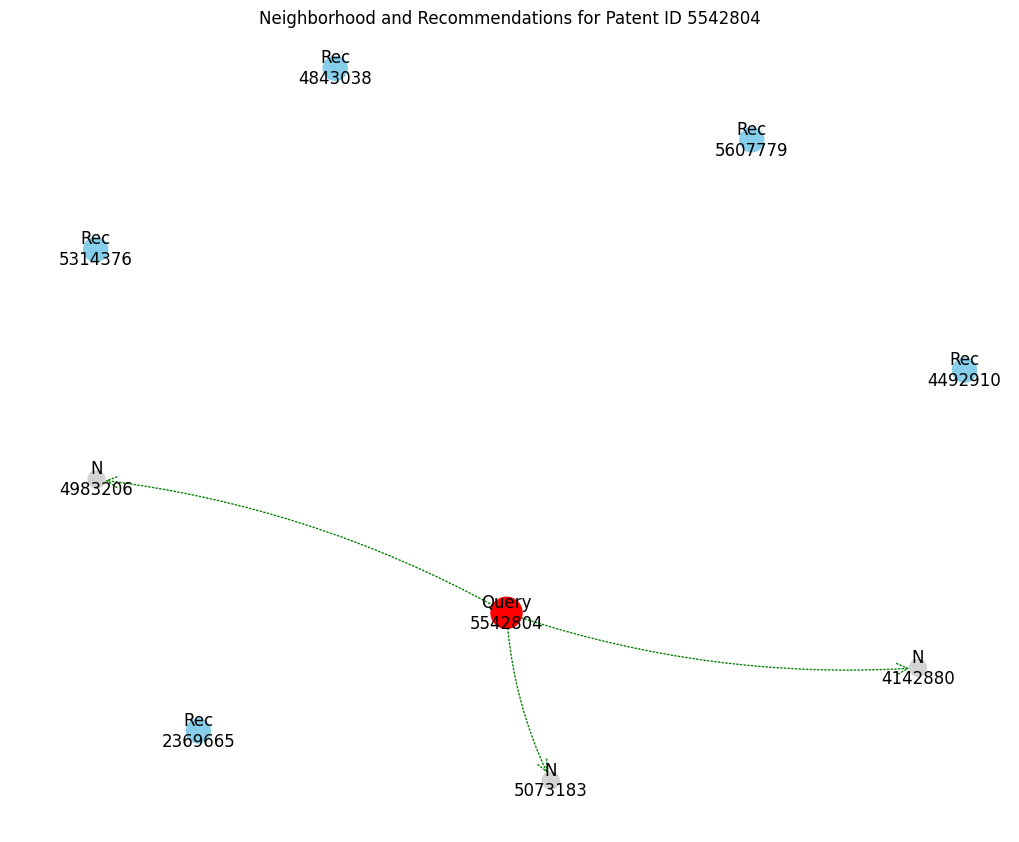

In [10]:
# Function to get recommendations for a given patent ID
def get_patent_recommendations(patent_id, model, node_mapping, all_nodes_original, k=10):

    if patent_id not in node_mapping:
        print(f"Warning: Patent ID {patent_id} not found in the graph.")
        return []

    # Get the mapped ID
    mapped_id = node_mapping[patent_id]

    # Ensure embeddings were generated successfully
    try:
        embeddings = model().detach().cpu().numpy()
    except RuntimeError:
        print("Error: Could not retrieve embeddings from the model. Ensure training completed successfully.")
        return []

    if mapped_id >= embeddings.shape[0]:
        print(f"Warning: Mapped ID {mapped_id} out of bounds for embeddings array (shape {embeddings.shape}).")
        return []

    query_embedding = embeddings[mapped_id].reshape(1, -1)

    # Calculate cosine similarity between the query embedding and all other embeddings
    from sklearn.metrics.pairwise import cosine_similarity
    similarities = cosine_similarity(query_embedding, embeddings)[0]

    top_k_indices = np.argsort(-similarities)[:k + 1]

    recommendations = []
    # Iterate through top indices
    for index in top_k_indices:
        # Map the index back to the original patent ID
        original_rec_id = all_nodes_original[index]

        # Exclude the query patent itself
        if original_rec_id != patent_id:
            recommendations.append((original_rec_id, similarities[index]))

    return recommendations

example_patent_id = 5542804 # Or choose one from your `top_cited` list

print(f"\nGetting recommendations for Patent ID {example_patent_id}:")
recommended_patents = get_patent_recommendations(example_patent_id, model, node_mapping, all_nodes_original, k=5)

if recommended_patents:
    print(f"Top 5 recommended patents for Patent ID {example_patent_id}:")
    for rec_patent, similarity in recommended_patents:
        print(f"- Patent ID: {rec_patent}, Similarity: {similarity:.4f}")
else:
    print(f"Could not retrieve recommendations for Patent ID {example_patent_id}.")


# Function to visualize a recommendation neighborhood
def visualize_recommendation_neighborhood(patent_id, recommended_patents, G, num_neighbors=5):
    if not recommended_patents:
        print("No recommendations to visualize.")
        return

    viz_graph = nx.DiGraph()

    # Add the query patent node
    viz_graph.add_node(patent_id, type='query')

    # Add recommended patent nodes
    recommended_ids = [rec[0] for rec in recommended_patents]
    for rec_id in recommended_ids:
         viz_graph.add_node(rec_id, type='recommended')

    # Add direct neighbors of the query patent
    query_neighbors = set(list(G.predecessors(patent_id)) + list(G.successors(patent_id)))
    # Limit to num_neighbors to keep the visualization manageable
    query_neighbors_sample = list(query_neighbors)[:num_neighbors]

    for neighbor_id in query_neighbors_sample:
        viz_graph.add_node(neighbor_id, type='neighbor')
        # Add edges between query and its neighbors
        if G.has_edge(neighbor_id, patent_id):
            viz_graph.add_edge(neighbor_id, patent_id, type='citation_in')
        if G.has_edge(patent_id, neighbor_id):
            viz_graph.add_edge(patent_id, neighbor_id, type='citation_out')

    # Add edges between the query patent and recommended patents (if they exist in the original graph)
    for rec_id in recommended_ids:
        if G.has_edge(patent_id, rec_id):
            viz_graph.add_edge(patent_id, rec_id, type='recommendation_citation') # Patent A cites Recommended B
        if G.has_edge(rec_id, patent_id):
             viz_graph.add_edge(rec_id, patent_id, type='citation_recommendation') # Recommended B cites Patent A

    # Define node colors and sizes based on type
    node_colors = []
    node_sizes = []
    node_labels = {}
    for node in viz_graph.nodes(data=True):
        node_id = node[0]
        node_attributes = node[1]
        if node_attributes['type'] == 'query':
            node_colors.append('red')
            node_sizes.append(500)
            node_labels[node_id] = f'Query\n{node_id}'
        elif node_attributes['type'] == 'recommended':
            node_colors.append('skyblue')
            node_sizes.append(300)
            node_labels[node_id] = f'Rec\n{node_id}'
        else: # neighbor
            node_colors.append('lightgray')
            node_sizes.append(150)
            node_labels[node_id] = f'N\n{node_id}' # Label neighbors simply

    # Define edge styles based on type (optional)
    edge_colors = []
    edge_styles = []
    for u, v, data in viz_graph.edges(data=True):
        if data.get('type') == 'recommendation_citation': # Query -> Recommended
             edge_colors.append('blue')
             edge_styles.append('solid')
        elif data.get('type') == 'citation_recommendation': # Recommended -> Query
             edge_colors.append('purple')
             edge_styles.append('dashed')
        elif data.get('type') == 'citation_in': # Neighbor -> Query
             edge_colors.append('orange')
             edge_styles.append('dotted')
        elif data.get('type') == 'citation_out': # Query -> Neighbor
             edge_colors.append('green')
             edge_styles.append('dotted')
        else:
             edge_colors.append('gray')
             edge_styles.append('solid')


    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(viz_graph, seed=42) # Use spring layout for visualization

    nx.draw(viz_graph, pos, with_labels=True, labels=node_labels,
            node_size=node_sizes, node_color=node_colors,
            edge_color=edge_colors, style=edge_styles,
            arrowstyle='->', arrowsize=20, connectionstyle='arc3,rad=0.1')

    plt.title(f'Neighborhood and Recommendations for Patent ID {patent_id}')
    plt.axis('off') # Hide axes
    plt.show()

# Example Usage: Visualize recommendations for the example patent ID
if recommended_patents:
    print(f"\nVisualizing recommendations for Patent ID {example_patent_id}:")
    visualize_recommendation_neighborhood(example_patent_id, recommended_patents, G, num_neighbors=3) # Show 3 neighbors





Getting recommendations for a different Patent ID: 1:
Top 5 recommended patents for Patent ID 1:
- Patent ID: 1220304, Similarity: 0.5840
- Patent ID: 4512078, Similarity: 0.5570
- Patent ID: 2302839, Similarity: 0.5529
- Patent ID: 5634296, Similarity: 0.5459
- Patent ID: 3486933, Similarity: 0.5440

Visualizing recommendations for Patent ID 1:


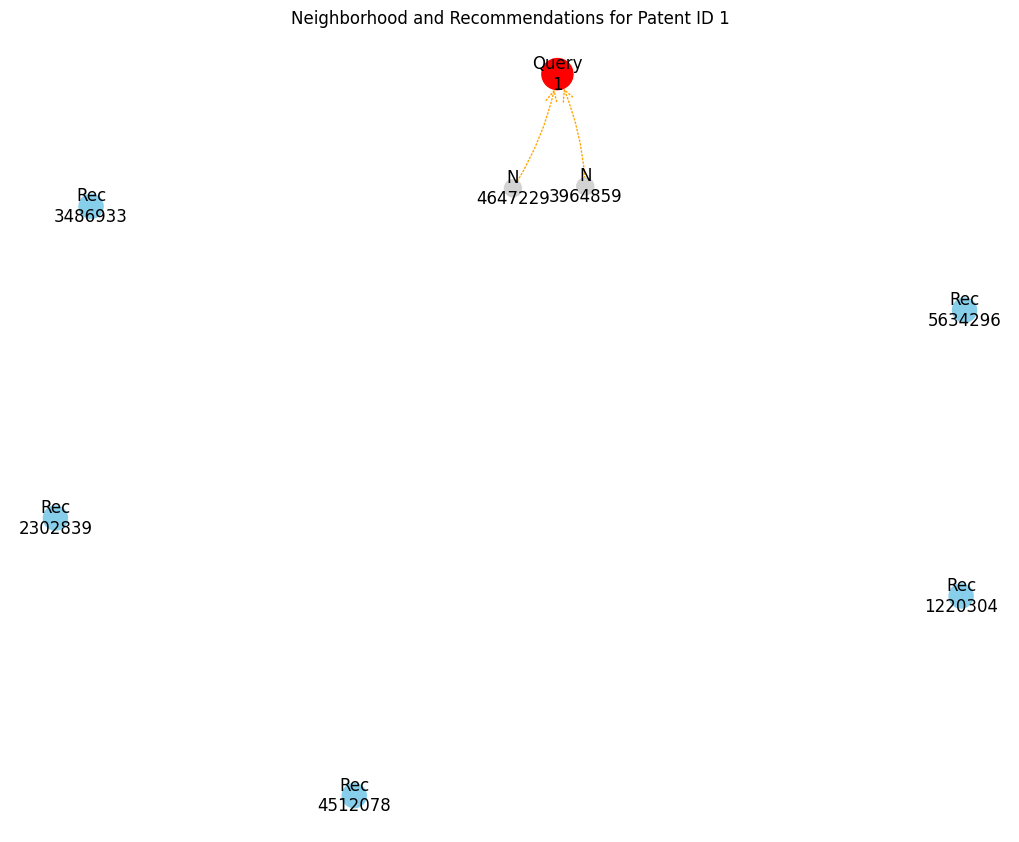

In [15]:
print(f"\nGetting recommendations for a different Patent ID: {another_example_patent_id}:")
another_recommended_patents = get_patent_recommendations(another_example_patent_id, model, node_mapping, all_nodes_original, k=5)

if another_recommended_patents:
    print(f"Top 5 recommended patents for Patent ID {another_example_patent_id}:")
    for rec_patent, similarity in another_recommended_patents:
        print(f"- Patent ID: {rec_patent}, Similarity: {similarity:.4f}")

    print(f"\nVisualizing recommendations for Patent ID {another_example_patent_id}:")
    visualize_recommendation_neighborhood(another_example_patent_id, another_recommended_patents, G, num_neighbors=3) # Show 3 neighbors
else:
    print(f"Could not retrieve recommendations for Patent ID {another_example_patent_id}.")